In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import joblib

from PIL import Image
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
dataset_path = r"D:\BrainTumorDetection\brain_tumor_dataset"

In [3]:
dataset_path = r"D:\BrainTumorDetection\brain_tumor_dataset"

yes_path = os.path.join(dataset_path, "yes")
no_path = os.path.join(dataset_path, "no")

print("Dataset path:", dataset_path)
print("YES folder exists:", os.path.exists(yes_path))
print("NO folder exists:", os.path.exists(no_path))

Dataset path: D:\BrainTumorDetection\brain_tumor_dataset
YES folder exists: True
NO folder exists: True


In [4]:
yes_files = os.listdir(yes_path)
no_files = os.listdir(no_path)

print("Tumor images (YES):", len(yes_files))
print("No tumor images (NO):", len(no_files))
print("Total images:", len(yes_files) + len(no_files))

Tumor images (YES): 155
No tumor images (NO): 98
Total images: 253


In [5]:
print("First 10 YES files:")
print(yes_files[:10])

print("\nFirst 10 NO files:")
print(no_files[:10])

First 10 YES files:
['Y1.jpg', 'Y10.jpg', 'Y100.JPG', 'Y101.jpg', 'Y102.jpg', 'Y103.jpg', 'Y104.jpg', 'Y105.jpg', 'Y106.jpg', 'Y107.jpg']

First 10 NO files:
['1 no.jpeg', '10 no.jpg', '11 no.jpg', '12 no.jpg', '13 no.jpg', '14 no.jpg', '15 no.jpg', '17 no.jpg', '18 no.jpg', '19 no.jpg']


In [6]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

yes_images = [
    f for f in os.listdir(yes_path)
    if f.lower().endswith(image_extensions)
]

no_images = [
    f for f in os.listdir(no_path)
    if f.lower().endswith(image_extensions)
]

print("Valid YES images:", len(yes_images))
print("Valid NO images:", len(no_images))

Valid YES images: 155
Valid NO images: 98


Image format: JPEG
Image size: (180, 218)
Image mode: RGB


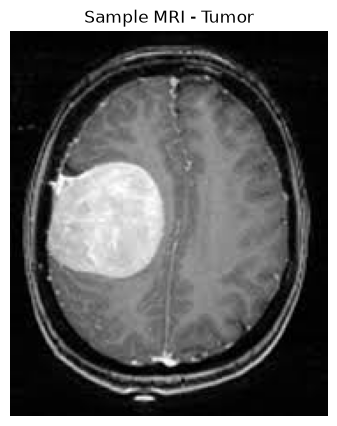

In [7]:
sample_yes_path = os.path.join(yes_path, yes_images[0])

img = Image.open(sample_yes_path)

print("Image format:", img.format)
print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Sample MRI - Tumor")
plt.axis("off")
plt.show()

Image format: JPEG
Image size: (630, 630)
Image mode: L


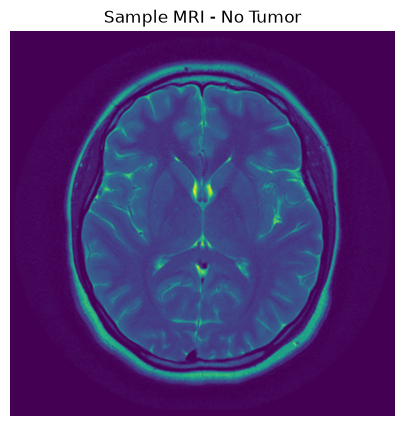

In [8]:
sample_no_path = os.path.join(no_path, no_images[0])

img = Image.open(sample_no_path)

print("Image format:", img.format)
print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Sample MRI - No Tumor")
plt.axis("off")
plt.show()

In [9]:
IMG_SIZE = (128, 128)

X_images = []
y = []

# Tumor = 1
for filename in yes_images:
    file_path = os.path.join(yes_path, filename)

    try:
        img = Image.open(file_path).convert("L")
        img = img.resize(IMG_SIZE)

        img_array = np.array(img)

        X_images.append(img_array)
        y.append(1)

    except Exception as e:
        print("Could not load:", file_path)
        print("Error:", e)


# No tumor = 0
for filename in no_images:
    file_path = os.path.join(no_path, filename)

    try:
        img = Image.open(file_path).convert("L")
        img = img.resize(IMG_SIZE)

        img_array = np.array(img)

        X_images.append(img_array)
        y.append(0)

    except Exception as e:
        print("Could not load:", file_path)
        print("Error:", e)


X_images = np.array(X_images)
y = np.array(y)

print("Images loaded:", len(X_images))
print("Image data shape:", X_images.shape)
print("Labels shape:", y.shape)

Images loaded: 253
Image data shape: (253, 128, 128)
Labels shape: (253,)


In [10]:
print("Tumor images:", np.sum(y == 1))
print("No tumor images:", np.sum(y == 0))

Tumor images: 155
No tumor images: 98


In [11]:
X_hog = []

for image in X_images:

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    X_hog.append(features)

X_hog = np.array(X_hog)

print("Original image shape:", X_images.shape)
print("HOG feature shape:", X_hog.shape)

Original image shape: (253, 128, 128)
HOG feature shape: (253, 8100)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 202
Testing samples: 51


In [13]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

print("HOG + SVM model created!")

HOG + SVM model created!


In [14]:
print("Training SVM...")

model.fit(X_train, y_train)

print("Training completed successfully!")

Training SVM...


D:\BrainTumorDetection\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training completed successfully!


In [15]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8823529411764706
Accuracy (%): 88.23529411764706


In [16]:

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Tumor", "Tumor"]
))

              precision    recall  f1-score   support

    No Tumor       0.89      0.80      0.84        20
       Tumor       0.88      0.94      0.91        31

    accuracy                           0.88        51
   macro avg       0.88      0.87      0.87        51
weighted avg       0.88      0.88      0.88        51



Confusion Matrix:
[[16  4]
 [ 2 29]]


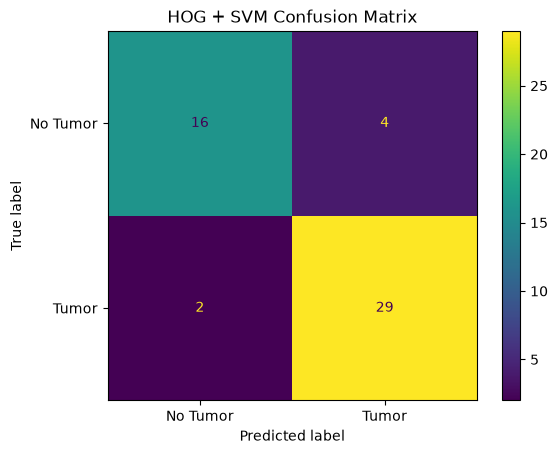

In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot()
plt.title("HOG + SVM Confusion Matrix")
plt.show()

In [18]:
model_folder = r"D:\BrainTumorDetection\model"

os.makedirs(model_folder, exist_ok=True)

model_path = os.path.join(
    model_folder,
    "hog_svm_model.pkl"
)

joblib.dump(model, model_path)

print("Model saved successfully!")
print("Location:", model_path)

Model saved successfully!
Location: D:\BrainTumorDetection\model\hog_svm_model.pkl


In [25]:
test_folder = yes_path

test_files = [
    f for f in os.listdir(test_folder)
    if f.lower().endswith(image_extensions)
]

test_image_path = os.path.join(
    test_folder,
    test_files[0]
)

print("Testing image:")
print(test_image_path)

Testing image:
D:\BrainTumorDetection\brain_tumor_dataset\yes\Y1.jpg


Test image shape: (128, 128)


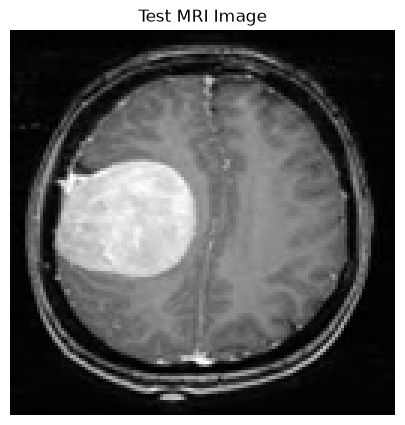

In [26]:
test_img = Image.open(test_image_path).convert("L")

test_img = test_img.resize(IMG_SIZE)

test_array = np.array(test_img)

print("Test image shape:", test_array.shape)

plt.figure(figsize=(5, 5))
plt.imshow(test_array, cmap="gray")
plt.title("Test MRI Image")
plt.axis("off")
plt.show()

In [27]:
test_hog = hog(
    test_array,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
)

test_hog = test_hog.reshape(1, -1)

print("Test HOG feature shape:", test_hog.shape)

Test HOG feature shape: (1, 8100)


In [28]:
prediction = model.predict(test_hog)[0]

if prediction == 1:
    result = "TUMOR DETECTED"
else:
    result = "NO TUMOR"

print("Prediction:", result)

Prediction: TUMOR DETECTED


In [29]:
prediction = model.predict(test_hog)[0]

if prediction == 1:
    result = "TUMOR DETECTED"
else:
    result = "NO TUMOR"

print("Prediction:", result)

Prediction: TUMOR DETECTED


In [30]:
probability = model.predict_proba(test_hog)[0]

print("No Tumor probability:", probability[0] * 100)
print("Tumor probability:", probability[1] * 100)

No Tumor probability: 8.885072129747783
Tumor probability: 91.1149278702522
